In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display every column
pd.options.display.max_rows = None
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('data_export_imputed05.csv')

## Feature Engineering

### Encoding

In [3]:
# Encoding
# TODO - 1. Make age groups (Binning), 2. Familysize groups (Binning)
# NOTES:
#- Look up binning in Meet 14 notes.
# - Binning is not necessary for Decision Trees (AI?)
# - Binning is necessary for Linear Regression (AI?)
# - Binning is necessary for Logistic Regression (AI?)
# - Binning is necessary for SVM (AI?)
 

#### Age Group

In [4]:
# Binning Age Group
df['age_group'] = pd.cut(df['age'], bins = [0, 18, 35, 50, 100], labels = ['0-18', '19-35', '36-50', '50+']) 

In [5]:
# Label encoding age_group
df['age_group_label_encoded'] = df['age_group'].replace({'0-18': 0, '19-35': 1, '36-50': 2, '50+': 3})

C:\Users\mfaiq\AppData\Local\Temp\ipykernel_32612\859349632.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['age_group_label_encoded'] = df['age_group'].replace({'0-18': 0, '19-35': 1, '36-50': 2, '50+': 3})
C:\Users\mfaiq\AppData\Local\Temp\ipykernel_32612\859349632.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['age_group_label_encoded'] = df['age_group'].replace({'0-18': 0, '19-35': 1, '36-50': 2, '50+': 3})


In [6]:
df.head()[['age', 'age_group', 'age_group_label_encoded']]

,age,age_group,age_group_label_encoded
0,16,0-18,0
1,16,0-18,0
2,17,0-18,0
3,13,0-18,0
4,19,19-35,1


Text(0.5, 1.0, 'Age Group Distribution')

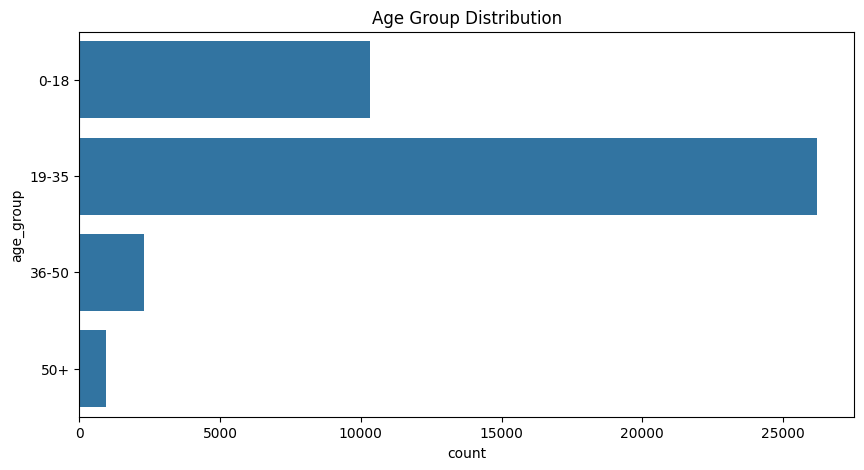

In [7]:
plt.figure(figsize=(10, 5))
sns.countplot(df['age_group'])
plt.title('Age Group Distribution')

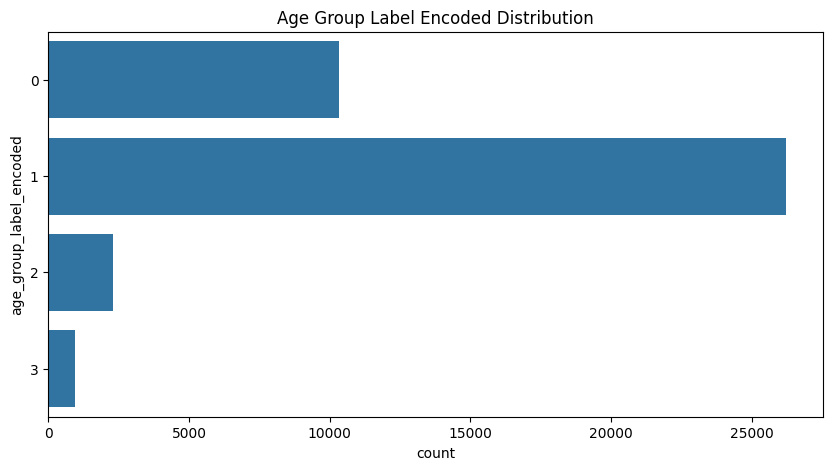

In [8]:
plt.figure(figsize=(10, 5))
sns.countplot(df['age_group_label_encoded'])
plt.title('Age Group Label Encoded Distribution')
plt.show()

#### Family Size Group

Note: Familysize Group is bugged as it produces NaN values.

In [9]:
# Binning Familysize Group
# df['familysize_group'] = pd.cut(df['familysize'], bins = [0, 2, 4, 6, 100], labels = ['0-2', '3-4', '5-6', '6+'])

In [10]:
# label encoding familysize_group
# df['familysize_group_label_encoded'] = df['familysize_group'].replace({'0-2': 0, '3-4': 1, '5-6': 2, '6+': 3})

In [11]:
# df['familysize_group'].describe()

In [12]:
# plt.figure(figsize=(10, 5))
# sns.countplot(df['familysize_group'])
# plt.title('Familysize Group Distribution')
# plt.show()

In [13]:
# plt.figure(figsize=(10, 5))
# sns.countplot(df['familysize_group_label_encoded'])
# plt.title('Familysize Group Label Encoded Distribution')
# plt.show()

### Total Depression, Anxiety, and Stress scores

In [14]:
depression_items = ['Q3A','Q5A','Q10A','Q13A','Q16A','Q17A','Q21A','Q24A','Q26A','Q31A','Q34A','Q37A','Q38A','Q42A']  # 14
anxiety_items    = ['Q2A','Q4A','Q7A','Q9A','Q15A','Q19A','Q20A','Q23A','Q25A','Q28A','Q30A','Q36A','Q40A','Q41A']  # 14
stress_items     = ['Q1A','Q6A','Q8A','Q11A','Q12A','Q14A','Q18A','Q22A','Q27A','Q29A','Q32A','Q33A','Q35A','Q39A']  # 14

df['depression'] = df[depression_items].sum(axis=1)
df['anxiety'] = df[anxiety_items].sum(axis=1)
df['stress'] = df[stress_items].sum(axis=1)

#### Multiclass Mapping for Depression, Anxiety, and Stress

Important as classifying Depression, Anxiety, and stress is not binary, according to the DASS Manual.

In [106]:
# 	               | Depression	    Anxiety	    Stress
# ----------------------------------------------------------------------
# Normal	       | 0-9	        0-7	        0-14
# Mild	           | 10-13	        8-9	        15-18
# Moderate	       | 14-20	        10-14	    19-25
# Severe	       | 21-27	        15-19	    26-33
# Extremely severe | 28+	        20+	        34+

In [107]:
# DASS items
depression_items = ['Q3A','Q5A','Q10A','Q13A','Q16A','Q17A','Q21A','Q24A','Q26A','Q31A','Q34A','Q37A','Q38A','Q42A']  # 14
anxiety_items    = ['Q2A','Q4A','Q7A','Q9A','Q15A','Q19A','Q20A','Q23A','Q25A','Q28A','Q30A','Q36A','Q40A','Q41A']  # 14
stress_items     = ['Q1A','Q6A','Q8A','Q11A','Q12A','Q14A','Q18A','Q22A','Q27A','Q29A','Q32A','Q33A','Q35A','Q39A']  # 14
dass_items = depression_items + anxiety_items + stress_items

# Create depression, anxiety, and stress scores
# Each item is rated on a 4-point scale (1 to 4)
df['depression'] = df[depression_items].sum(axis=1) # Subtract 1 from each item before summing
df['anxiety'] = df[anxiety_items].sum(axis=1) # Scoring needs the ordinal to be 0-3 instead of 1-4.
df['stress'] = df[stress_items].sum(axis=1)

# Multiclass mapping for Depression, Anxiety, and Stress

# Map the scores to their respective categories
def map_depression(score):
    if score <= 9:
        return 0 # 'Normal'
    elif score <= 13:
        return 1 # 'Mild'
    elif score <= 20:
        return 2 # 'Moderate'
    elif score <= 27:
        return 3 # 'Severe'
    else:
        return 4 # 'Extremely severe'
    
def map_anxiety(score):
    if score <= 7:
        return 0 # 'Normal'
    elif score <= 9:
        return 1 # 'Mild'
    elif score <= 14:
        return 2 # 'Moderate'
    elif score <= 19:
        return 3 # 'Severe'
    else:
        return 4 # 'Extremely severe'
    
def map_stress(score):
    if score <= 14:
        return 0 # 'Normal'
    elif score <= 18:
        return 1 # 'Mild'
    elif score <= 25:
        return 2 # 'Moderate'
    elif score <= 33:
        return 3 # 'Severe'
    else:
        return 4 # 'Extremely severe'

# Apply the mapping functions to create new columns
df['depression_class'] = df['depression'].apply(map_depression)
df['anxiety_class'] = df['anxiety'].apply(map_anxiety)
df['stress_class'] = df['stress'].apply(map_stress)

In [108]:
# Show depression, anxiety, and stress class distribution
depression_class_counts = df['depression_class'].value_counts().sort_index()
anxiety_class_counts = df['anxiety_class'].value_counts().sort_index()
stress_class_counts = df['stress_class'].value_counts().sort_index()

depression_class_counts, anxiety_class_counts, stress_class_counts

(depression_class
 0     8856
 1     3786
 2     7079
 3     6477
 4    13577
 Name: count, dtype: int64,
 anxiety_class
 0     9728
 1     2764
 2     7048
 3     6113
 4    14122
 Name: count, dtype: int64,
 stress_class
 0    11800
 1     4921
 2     8730
 3     8575
 4     5749
 Name: count, dtype: int64)

In [109]:
df.head()

,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,Q4I,Q4E,Q5A,Q5I,Q5E,Q6A,Q6I,Q6E,Q7A,Q7I,Q7E,Q8A,Q8I,Q8E,Q9A,Q9I,Q9E,Q10A,Q10I,Q10E,Q11A,Q11I,Q11E,Q12A,Q12I,Q12E,Q13A,Q13I,Q13E,Q14A,Q14I,Q14E,Q15A,Q15I,Q15E,Q16A,Q16I,Q16E,Q17A,Q17I,Q17E,Q18A,Q18I,Q18E,Q19A,Q19I,Q19E,Q20A,Q20I,Q20E,Q21A,Q21I,Q21E,Q22A,Q22I,Q22E,Q23A,Q23I,Q23E,Q24A,Q24I,Q24E,Q25A,Q25I,Q25E,Q26A,Q26I,Q26E,Q27A,Q27I,Q27E,Q28A,Q28I,Q28E,Q29A,Q29I,Q29E,Q30A,Q30I,Q30E,Q31A,Q31I,Q31E,Q32A,Q32I,Q32E,Q33A,Q33I,Q33E,Q34A,Q34I,Q34E,Q35A,Q35I,Q35E,Q36A,Q36I,Q36E,Q37A,Q37I,Q37E,Q38A,Q38I,Q38E,Q39A,Q39I,Q39E,Q40A,Q40I,Q40E,Q41A,Q41I,Q41E,Q42A,Q42I,Q42E,country,source,introelapse,testelapse,surveyelapse,TIPI1,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10,VCL1,VCL2,VCL3,VCL4,VCL5,VCL6,VCL7,VCL8,VCL9,VCL10,VCL11,VCL12,VCL13,VCL14,VCL15,VCL16,education,urban,gender,engnat,age,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize,age_group,age_group_label_encoded,depression,anxiety,stress,depression_class,anxiety_class,stress_class
0,3,28,3890.0,3,25,2122.0,1,16,1944.0,3,8,2044.0,3,34,2153.0,3,33,2416.0,3,10,2818.0,3,13,2259.0,1,21,5541.0,0,38,4441.0,3,31,2451.0,3,24,3325.0,3,14,1416.0,3,37,5021.0,3,27,2342.0,3,39,2480.0,2,6,2476.0,3,35,1627.0,2,17,9050.0,2,30,7001.0,0,11,4719.0,3,20,2984.0,3,36,1313.0,3,42,2444.0,3,1,9880.0,3,2,4695.0,3,5,1677.0,2,4,6723.0,3,3,5953.0,1,26,8062.0,3,12,5560.0,3,7,3032.0,1,29,3316.0,2,40,3563.0,3,23,5594.0,3,41,1477.0,0,18,3885.0,1,9,5265.0,3,19,1892.0,2,22,4228.0,3,32,1574.0,3,15,2969.0,IN,2,19.0,167.0,166.0,1,5,7,7,7,7,7,5,1,1,1,0,0,1,1,0,1,0,0,1,0,0,0,1,1,1,2.0,3.0,2.0,2.0,16,1,1,1.0,12.0,1.0,1,2.0,1.0,2,0-18,0,27,34,40,3,4,4
1,3,2,8118.0,0,36,2890.0,1,35,4777.0,2,28,3090.0,3,10,5078.0,3,40,2790.0,2,18,3408.0,3,1,8342.0,2,37,916.0,1,32,1537.0,1,21,3926.0,1,25,3691.0,3,26,2004.0,3,4,8888.0,2,27,4109.0,2,19,4058.0,3,12,3692.0,1,6,3373.0,0,23,6015.0,0,16,3023.0,1,22,2670.0,2,3,5727.0,0,39,3641.0,1,33,2670.0,1,7,7649.0,2,11,2537.0,2,5,2907.0,3,9,1685.0,2,41,4726.0,2,17,6063.0,1,20,3307.0,2,14,4995.0,2,38,2505.0,1,34,2540.0,1,31,4359.0,2,15,3925.0,3,13,4609.0,1,30,3755.0,1,42,2323.0,0,24,5713.0,1,8,1334.0,1,29,5562.0,US,2,1.0,193.0,186.0,6,5,4,7,5,4,7,7,1,5,1,1,0,1,1,0,0,0,0,1,0,0,0,1,1,1,2.0,3.0,2.0,1.0,16,2,1,2.0,7.0,1.0,7,2.0,1.0,4,0-18,0,24,17,27,3,3,3
2,2,7,5784.0,0,33,4373.0,3,41,3242.0,0,13,6470.0,3,11,3927.0,2,9,3704.0,0,17,4550.0,2,5,3021.0,1,32,5864.0,3,21,3722.0,1,10,3424.0,0,36,3236.0,3,23,2489.0,0,34,7290.0,3,12,6587.0,3,22,3627.0,3,38,2905.0,1,18,2998.0,1,8,10233.0,0,16,4258.0,3,28,2888.0,2,4,3180.0,1,3,11732.0,3,2,8834.0,1,29,7358.0,0,30,4928.0,1,15,3036.0,0,19,4127.0,1,37,3934.0,1,26,10782.0,3,1,8273.0,2,39,3501.0,0,27,3824.0,3,25,2141.0,2,6,17461.0,3,24,1557.0,3,40,4446.0,3,42,1883.0,1,35,5790.0,1,14,4432.0,0,20,2203.0,3,31,5768.0,PL,2,5.0,271.0,122.0,2,5,2,2,5,6,5,5,3,2,1,0,0,1,1,0,0,0,0,0,1,0,0,1,1,1,2.0,3.0,2.0,2.0,17,2,1,1.0,4.0,3.0,6,1.0,1.0,3,0-18,0,39,12,17,4,2,1
3,1,23,5081.0,2,11,6837.0,1,37,5521.0,0,27,4556.0,2,28,3269.0,2,26,3231.0,3,2,7138.0,1,19,3079.0,2,31,9650.0,2,17,4179.0,1,5,5928.0,0,21,2838.0,0,20,2560.0,3,29,5139.0,1,22,3597.0,1,35,3336.0,2,10,4506.0,0,14,2695.0,0,25,8128.0,1,15,3125.0,0,6,4061.0,0,40,4272.0,0,12,4029.0,0,9,5630.0,0,18,30631.0,1,24,9870.0,3,4,2411.0,0,16,9478.0,2,1,7618.0,2,32,12639.0,2,34,5378.0,0,41,8923.0,1,38,2977.0,3,3,5620.0,0,7,16760.0,0,8,6427.0,1,39,3760.0,0,13,4112.0,2,42,2769.0,3,33,4432.0,3,30,3643.0,1,36,3698.0,US,2,3.0,261.0,336.0,1,1,7,4,6,4,6,1,6,1,1,0,0,1,1,0,0,0,0,1,0,0,0,1,1,1,1.0,3.0,2.0,1.0,13,2,1,2.0,4.0,5.0,7,2.0,1.0,5,0-18,0,16,17,16,2,3,1
4,1,36,3215.0,1,13,7731.0,2,5,4156.0,3,10,2802.0,3,2,5628.0,1,9,6522.0,3,34,2374.0,3,11,3054.0,3,7,2975.0,2,14,3524.0,1,33,3033.0,3,23,2132.0,3,17,1314.0,3,16,3181.0,3,26,2249.0,2,19,2623.0,3,35,3093.0,3,38,7098.0,3,37,1938.0,3,15,3502.0,2,32,4776.0,2,18,4463.0,3,4,2436.0,1,40,4047.0,3,31,3787.0,3,42,2102.0,1,1,12351.0,3,3,2410.0,1,22,5056.0,3,39,3343.0,2,27,3012.0,3,20,3520.0,3,8,1868.0,3,25,2536.0,2,2

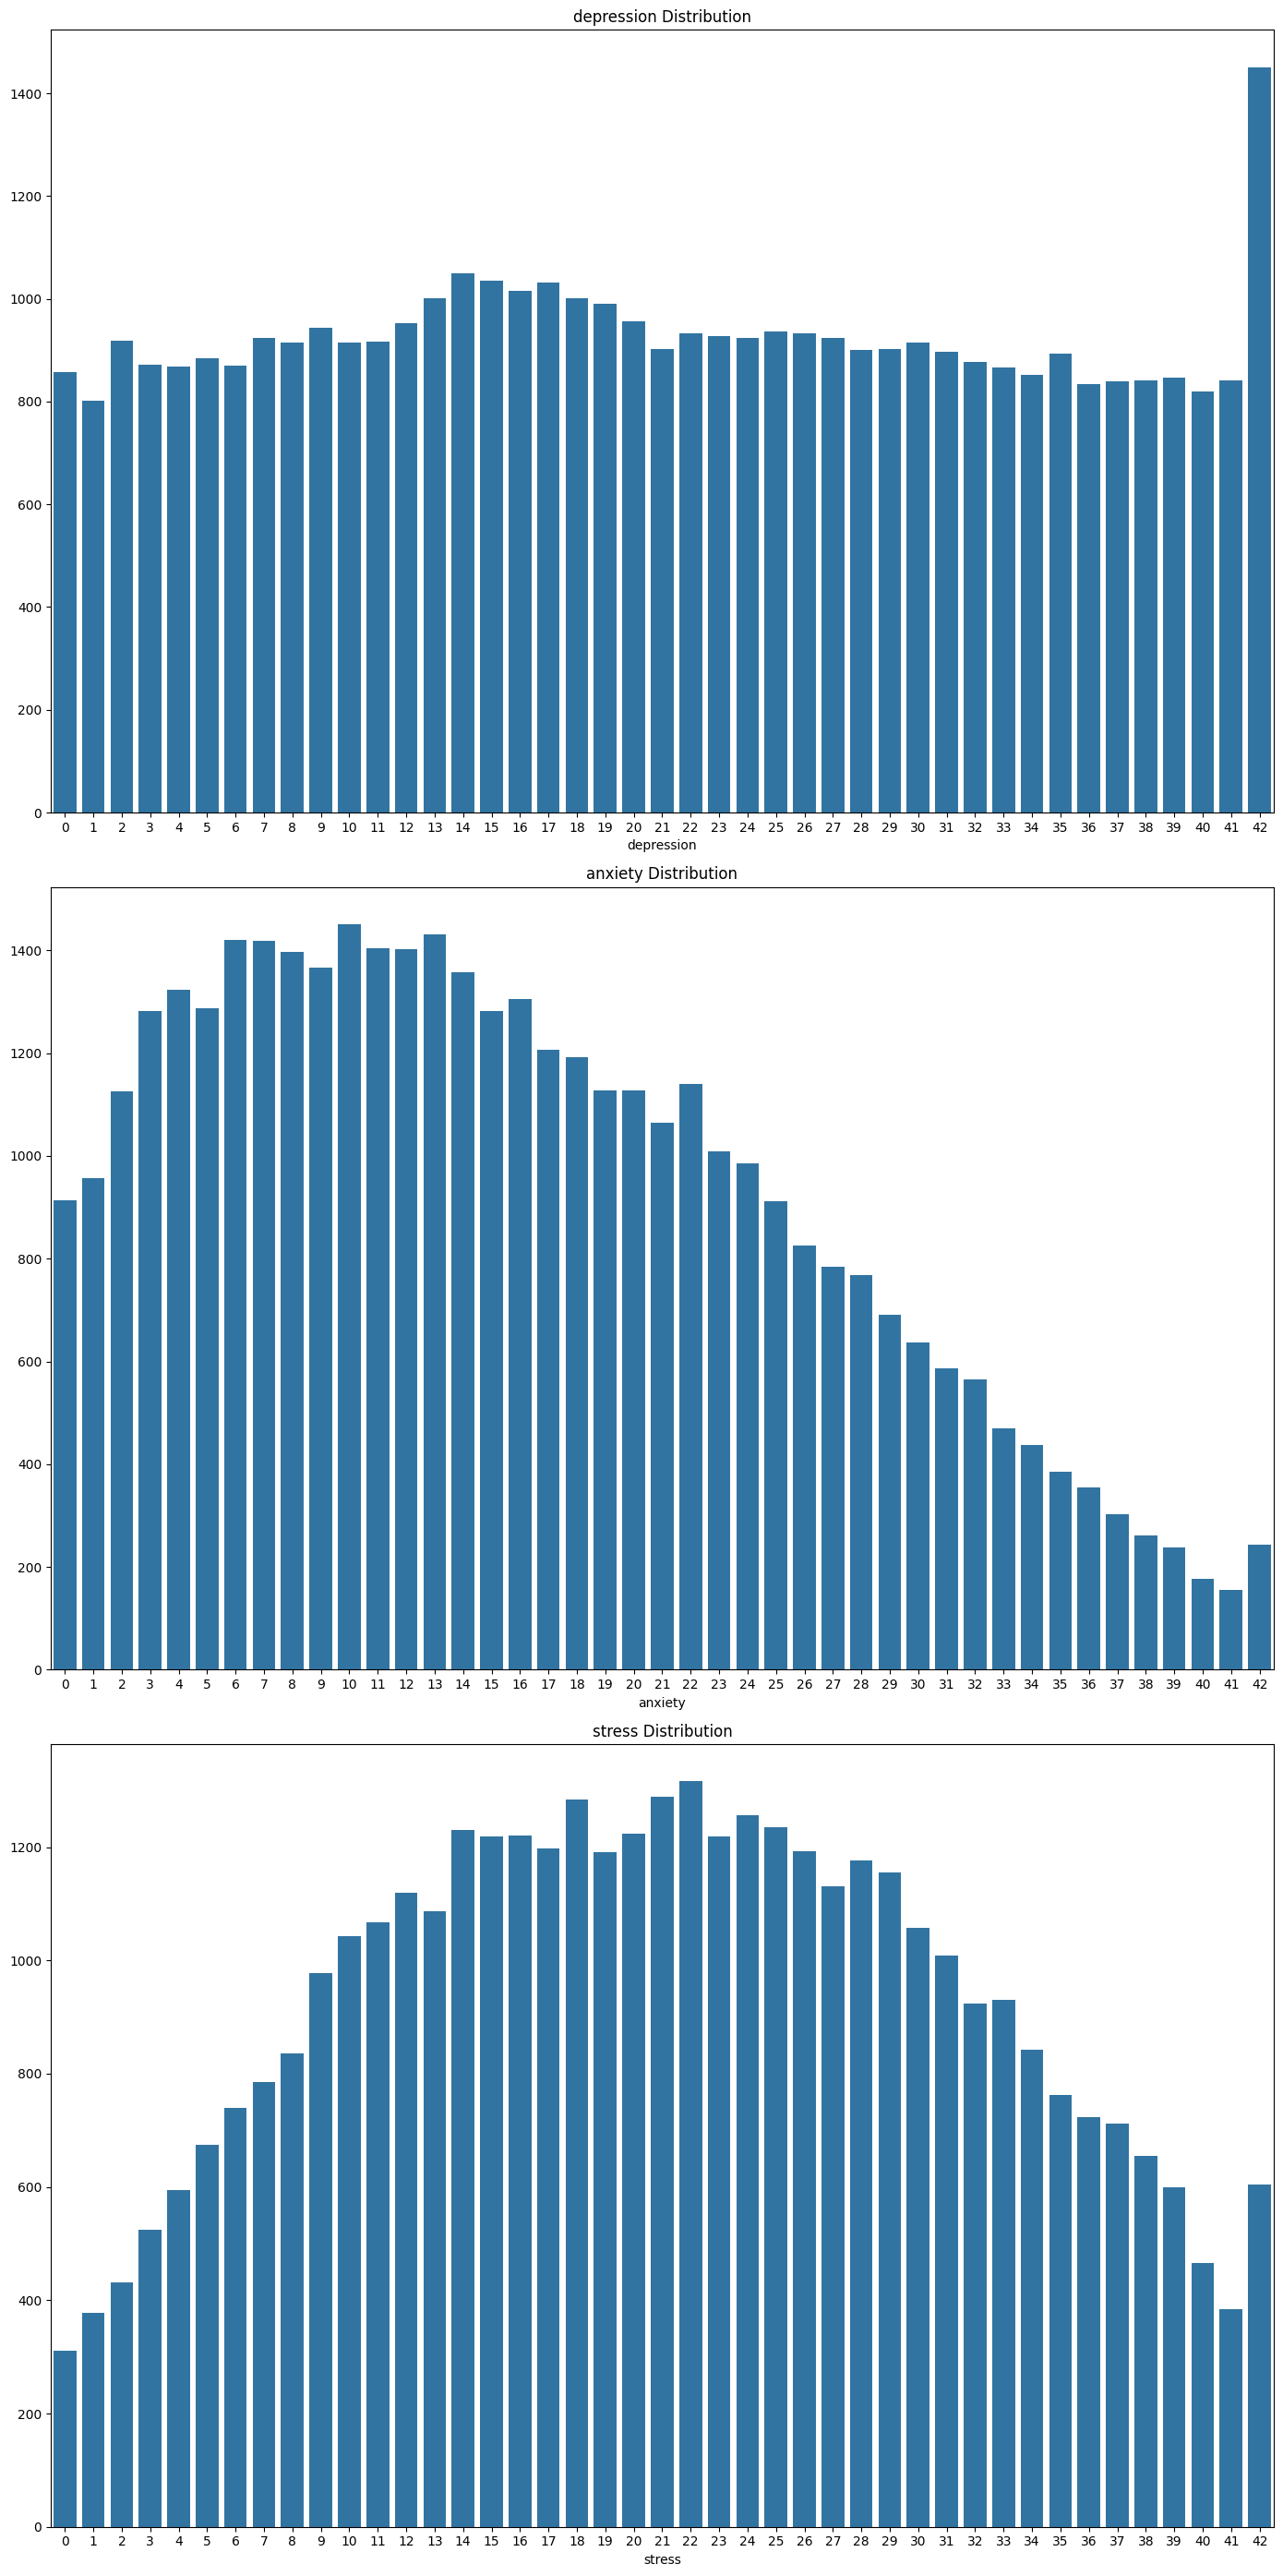

In [110]:
# DASS Classification Visualization
headers = ['depression', 'anxiety', 'stress']

fig, ax = plt.subplots(3, figsize=(14, 28))

fig.subplots_adjust(hspace=0.5)

for i, values in enumerate(headers):
    header_counts = df[values].value_counts()
    sns.barplot(x = header_counts.index, y = header_counts.values, ax=ax[i])
    ax[i].set_title(f'{values} Distribution')

fig.tight_layout()
plt.show()


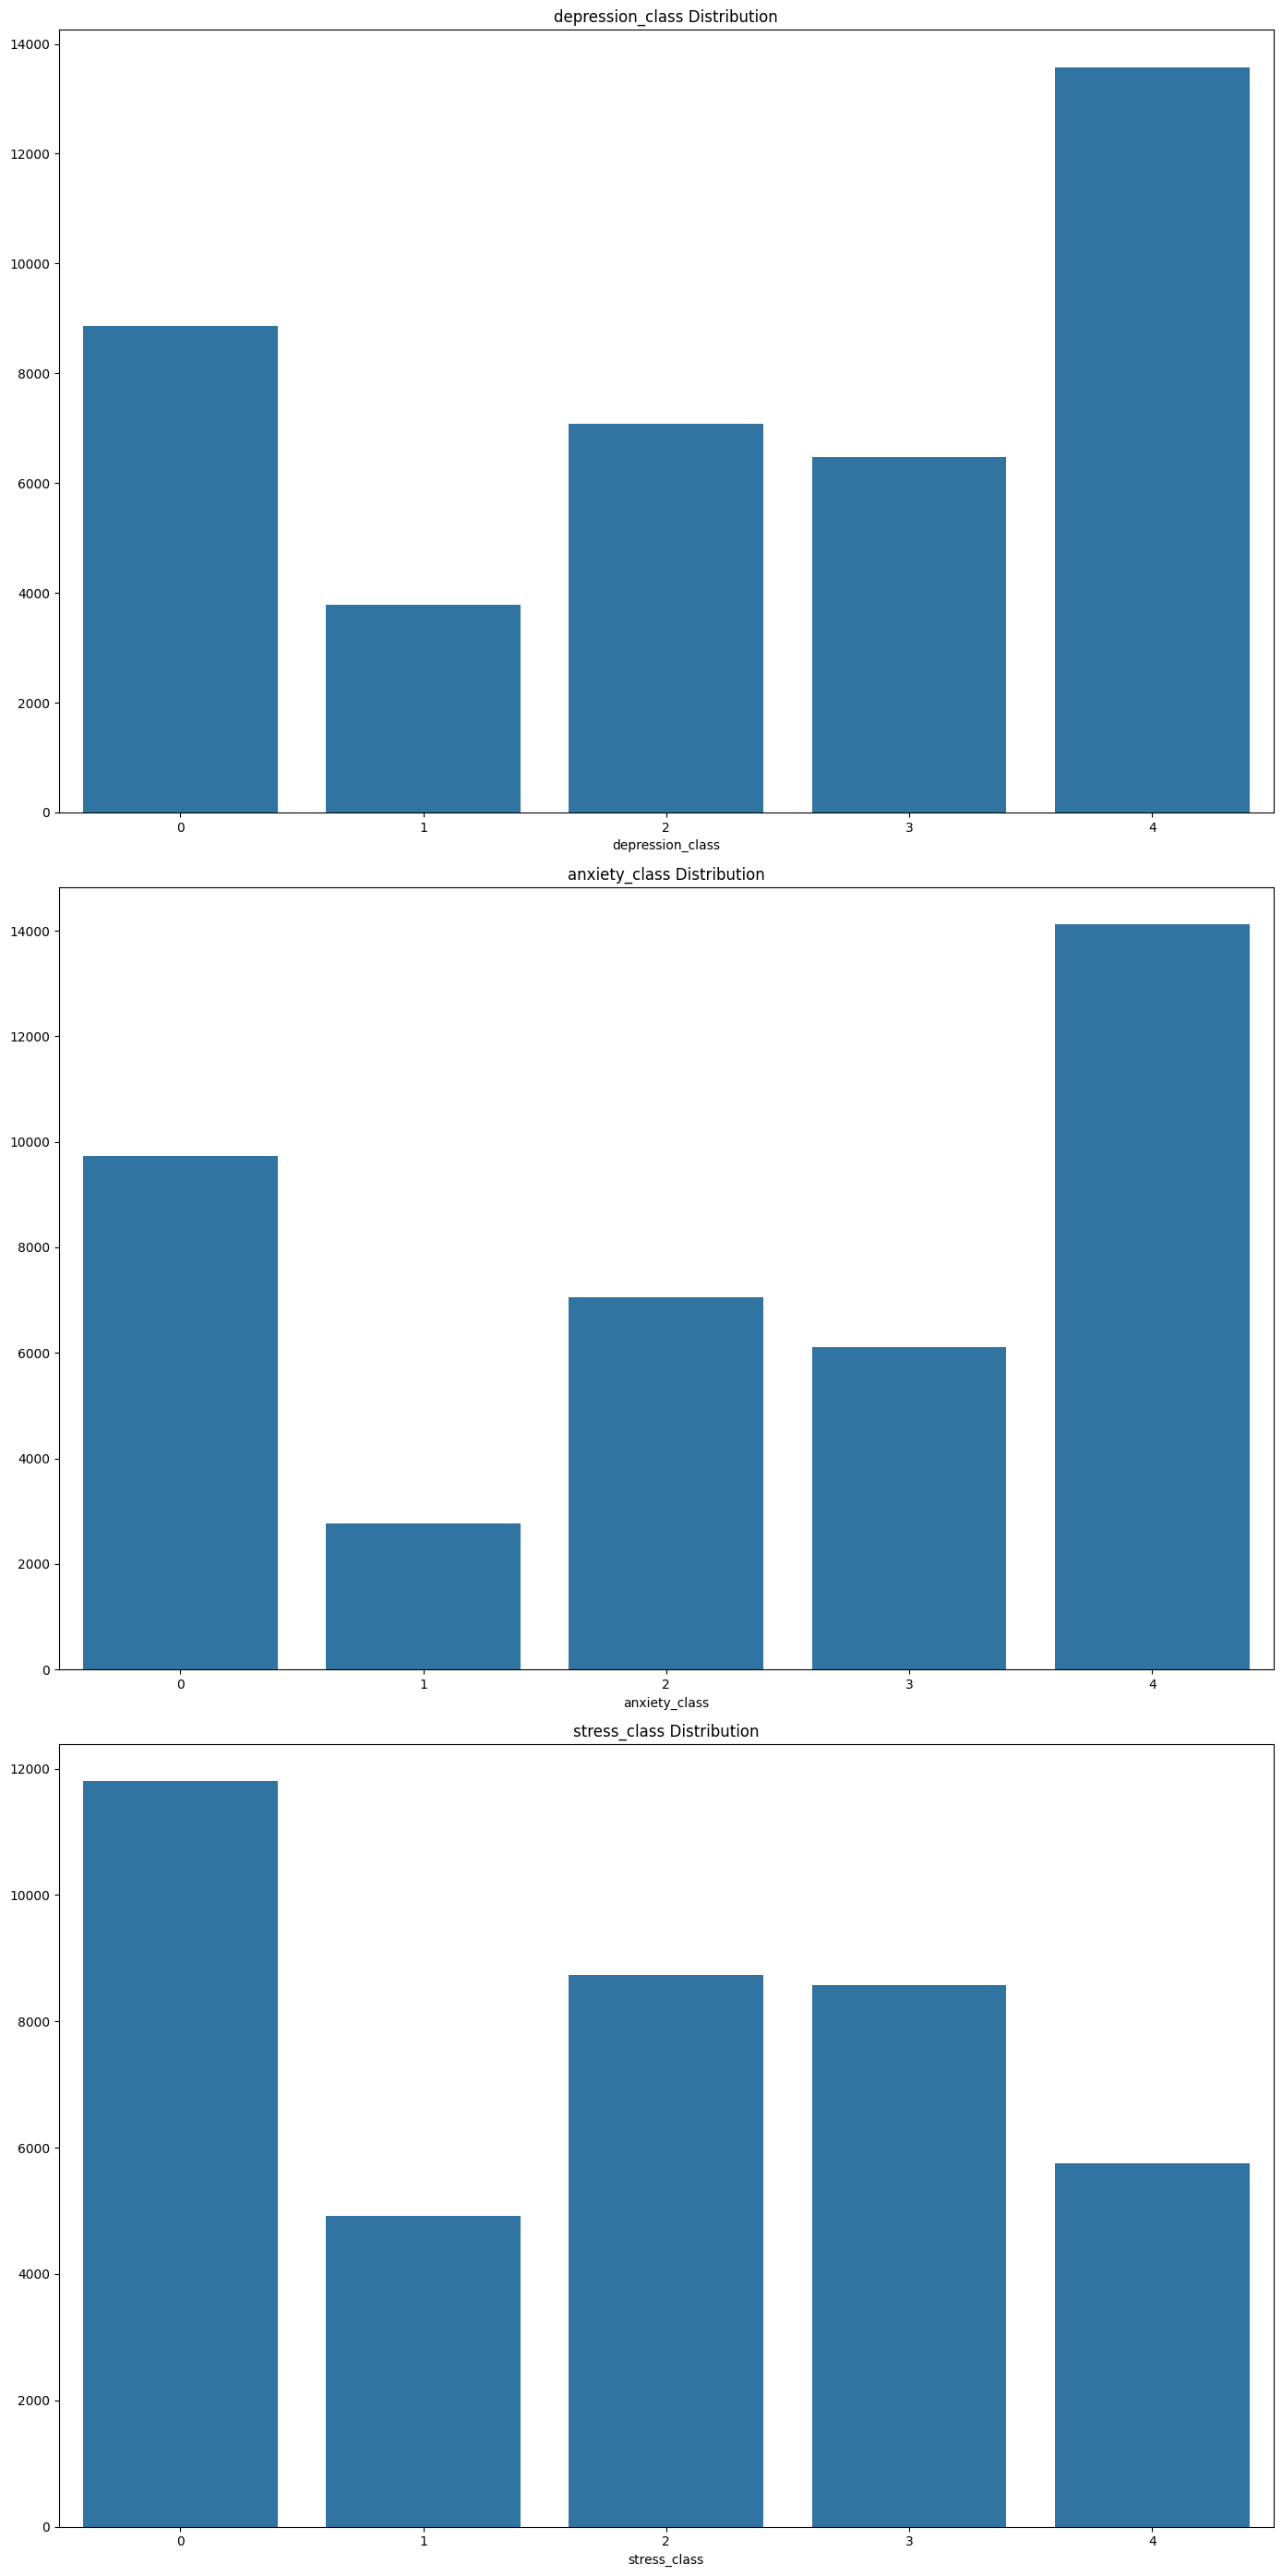

In [111]:
# DASS Classification Visualization
headers = ['depression_class', 'anxiety_class', 'stress_class']

fig, ax = plt.subplots(3, figsize=(14, 28))

fig.subplots_adjust(hspace=0.5)

for i, values in enumerate(headers):
    header_counts = df[values].value_counts()
    sns.barplot(x = header_counts.index, y = header_counts.values, ax=ax[i])
    ax[i].set_title(f'{values} Distribution')

fig.tight_layout()
plt.show()


In [112]:
depression_items = ['Q3A', 'Q5A', 'Q10A', 'Q13A', 'Q16A', 'Q17A', 'Q21A', 'Q24A', 'Q26A', 'Q31A', 'Q34A', 'Q37A', 'Q38A', 'Q42A']
anxiety_items = ['Q2A', 'Q4A', 'Q7A', 'Q9A', 'Q15A', 'Q19A', 'Q20A', 'Q23A', 'Q25A', 'Q28A', 'Q30A', 'Q36A', 'Q40A', 'Q41A']
stress_items = ['Q1A', 'Q6A', 'Q8A', 'Q11A', 'Q12A', 'Q14A', 'Q18A', 'Q22A', 'Q27A', 'Q29A', 'Q32A', 'Q33A', 'Q35A', 'Q39A']

In [113]:
df.head()[depression_items + ['depression', 'depression_class']]

,Q3A,Q5A,Q10A,Q13A,Q16A,Q17A,Q21A,Q24A,Q26A,Q31A,Q34A,Q37A,Q38A,Q42A,depression,depression_class
0,1,3,0,3,3,2,0,3,3,3,2,0,1,3,27,3
1,1,3,1,3,2,3,1,1,2,1,1,3,1,1,24,3
2,3,3,3,3,3,3,3,3,0,3,3,3,3,3,39,4
3,1,2,2,0,1,2,0,0,1,2,3,1,0,1,16,2
4,2,3,2,3,2,3,2,1,3,2,3,2,2,2,32,4


In [114]:
df.head()[anxiety_items + ['anxiety', 'anxiety_class']]

,Q2A,Q4A,Q7A,Q9A,Q15A,Q19A,Q20A,Q23A,Q25A,Q28A,Q30A,Q36A,Q40A,Q41A,anxiety,anxiety_class
0,3,3,3,1,3,2,2,3,3,2,1,3,2,3,34,4
1,0,2,2,2,2,0,0,0,1,3,2,2,0,1,17,3
2,0,0,0,1,3,1,0,1,1,0,1,3,1,0,12,2
3,2,0,3,2,1,0,1,0,0,0,2,0,3,3,17,3
4,1,3,3,3,3,3,3,3,3,3,3,3,3,3,40,4


In [115]:
df.head()[stress_items + ['stress', 'stress_class']]

,Q1A,Q6A,Q8A,Q11A,Q12A,Q14A,Q18A,Q22A,Q27A,Q29A,Q32A,Q33A,Q35A,Q39A,stress,stress_class
0,3,3,3,3,3,3,3,3,3,3,3,1,3,3,40,4
1,3,3,3,1,1,3,1,2,2,2,2,2,1,1,27,3
2,2,2,2,1,0,0,1,2,1,1,2,0,2,1,17,1
3,1,2,1,1,0,3,0,0,3,2,0,1,0,2,16,1
4,1,1,3,1,3,3,3,2,1,1,3,3,2,2,29,3


In [116]:
# Notes:
# - The results shows class imbalance for this dataset. 
# - Missing classification for 'Normal' (0) and 'Mild' (1) classes for Depression
# - Missing classification for 'Normal' (0) and 'Mild' (1) classes for Anxiety
# - Stress has every classification.
# - Can implement class weighting to balance the classes, but it's out of scope for this project. Could be added in the "Limitations" section of the report.

# For example:
# "While class imbalance was partially addressed using class weights,
#  further performance improvements might be achieved using SMOTE or threshold optimization,
#  which were beyond the scope of this study."

### Total Ten Item Personality Inventory (TIPI) scores

In [117]:
# Create OCEAN Columns
df['openness']            = (df['TIPI5'] + (8 - df['TIPI10'])) / 2 # Average of two items, 
df['conscientiousness']   = (df['TIPI3'] + (8 - df['TIPI8']))  / 2 # one positively keyed and one negatively keyed (reversed)
df['extraversion']        = (df['TIPI1'] + (8 - df['TIPI6']))  / 2 # Reversed items: TIPI2, TIPI4, TIPI6, TIPI8, TIPI10
df['agreeableness']       = (df['TIPI7'] + (8 - df['TIPI2']))  / 2 
df['emotional_stability'] = (df['TIPI9'] + (8 - df['TIPI4']))  / 2

# Create OCEAN Interaction Terms
df['interaction_openness']            = df['TIPI5'] * (8 - df['TIPI10'])
df['interaction_conscientiousness']   = df['TIPI3'] * (8 - df['TIPI8'])
df['interaction_extraversion']        = df['TIPI1'] * (8 - df['TIPI6'])
df['interaction_agreeableness']       = df['TIPI7'] * (8 - df['TIPI2'])
df['interaction_emotional_stability'] = df['TIPI9'] * (8 - df['TIPI4'])

In [118]:
# Check if TIPI scores are calculated correctly 
openness = ['TIPI5', 'TIPI10', 'openness']
conscientiousness = ['TIPI3', 'TIPI8', 'conscientiousness']
extraversion = ['TIPI1', 'TIPI6', 'extraversion']
agreeableness = ['TIPI7', 'TIPI2', 'agreeableness']
emotional_stability = ['TIPI9', 'TIPI4', 'emotional_stability']

df.head()[openness + conscientiousness + extraversion + agreeableness + emotional_stability]

,TIPI5,TIPI10,openness,TIPI3,TIPI8,conscientiousness,TIPI1,TIPI6,extraversion,TIPI7,TIPI2,agreeableness,TIPI9,TIPI4,emotional_stability
0,7,1,7.0,7,5,5.0,1,7,1.0,7,5,5.0,1,7,1.0
1,5,5,4.0,4,7,2.5,6,4,5.0,7,5,5.0,1,7,1.0
2,5,2,5.5,2,5,2.5,2,6,2.0,5,5,4.0,3,2,4.5
3,6,1,6.5,7,1,7.0,1,4,2.5,6,1,6.5,6,4,5.0
4,5,3,5.0,3,6,2.5,2,5,2.5,5,5,4.0,3,6,2.5


In [119]:
df.describe()[openness]

,TIPI5,TIPI10,openness
count,39775.000000,39775.000000,39775.000000
mean,4.997486,3.784261,4.606612
std,1.629986,1.813540,1.329669
min,1.000000,1.000000,1.000000
25%,4.000000,2.000000,4.000000
50%,5.000000,4.000000,4.500000
75%,6.000000,5.000000,5.500000
max,7.000000,7.000000,7.000000


### Interaction Terms

Combining two correlated features. Helps the model to process them efficiently.

#### Demographic Features

In [120]:
# Create interaction terms

# Define interaction terms as tuples
# TODO: Based on correlation matrix. Change interaction terms based on advanced feature selection (i.e RFE) later.

interaction_pairs = [
    # Depression
    ('education', 'age'), # Education - Age 
    ('education', 'voted'), # Education - Voted
    ('education', 'married'), # Education - Married
    ('voted', 'married'), # Voted - Married
    ('voted', 'age'), # Voted - Age
    ('married', 'age'), # Married - Age

    # Anxiety
    ('gender', 'age'), # Gender - Age
    ('gender', 'religion'), # Gender - Religion
    ('gender', 'orientation'), # Gender - Orientation

    # Stress
    # ('gender', 'engnat')  # Excluded - Engnat has low correlation with DASS
]

# Initialize an empty list. Used to store the interaction terms created. Output later using df.head()
interaction_columns = []

# For loop used to create interaction terms using the previous interaction pairs.
for feature1, feature2 in interaction_pairs:
    col_name = f'interaction_{feature1}_{feature2}'
    df[col_name] = df[feature1] * df[feature2]
    interaction_columns.append(feature1)
    interaction_columns.append(feature2)
    interaction_columns.append(col_name)

df.head()[interaction_columns]

,education,age,interaction_education_age,education,voted,interaction_education_voted,education,married,interaction_education_married,voted,married,interaction_voted_married,voted,age,interaction_voted_age,married,age,interaction_married_age,gender,age,interaction_gender_age,gender,religion,interaction_gender_religion,gender,orientation,interaction_gender_orientation
0,2.0,16,32.0,2.0,2.0,4.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,16,32.0,1.0,16,16.0,2.0,16,32.0,2.0,12.0,24.0,2.0,1.0,2.0
1,2.0,16,32.0,2.0,2.0,4.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,16,32.0,1.0,16,16.0,2.0,16,32.0,2.0,7.0,14.0,2.0,1.0,2.0
2,2.0,17,34.0,2.0,1.0,2.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,17,17.0,1.0,17,17.0,2.0,17,34.0,2.0,4.0,8.0,2.0,3.0,6.0
3,1.0,13,13.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,2.0,2.0,13,26.0,1.0,13,13.0,2.0,13,26.0,2.0,4.0,8.0,2.0,5.0,10.0
4,3.0,19,57.0,3.0,2.0,6.0,3.0,1.0,3.0,2.0,1.0,2.0,2.0,19,38.0,1.0,19,19.0,2.0,19,38.0,2.0,10.0,20.0,2.0,1.0,2.0


Everything works as intended

#### Ten Item Personality Item (TIPI) Features

Instead of using correlated TIPI features, correlated OCEAN features are used. This is because it will simplify and reduce the amount of features needed to make new interaction terms, possibly making the model perform better.

In [121]:
from itertools import combinations

ocean_headers = ['openness', 'conscientiousness', 'extraversion', 'agreeableness', 'emotional_stability']

for ocean, ocean2 in combinations(ocean_headers, 2):
    df[f'interaction_{ocean}_{ocean2}'] = df[ocean] * df[ocean2]

df.head()[[f'interaction_{ocean}_{ocean2}' for ocean, ocean2 in combinations(ocean_headers, 2)]]

,interaction_openness_conscientiousness,interaction_openness_extraversion,interaction_openness_agreeableness,interaction_openness_emotional_stability,interaction_conscientiousness_extraversion,interaction_conscientiousness_agreeableness,interaction_conscientiousness_emotional_stability,interaction_extraversion_agreeableness,interaction_extraversion_emotional_stability,interaction_agreeableness_emotional_stability
0,35.00,7.00,35.00,7.00,5.00,25.0,5.00,5.00,1.00,5.0
1,10.00,20.00,20.00,4.00,12.50,12.5,2.50,25.00,5.00,5.0
2,13.75,11.00,22.00,24.75,5.00,10.0,11.25,8.00,9.00,18.0
3,45.50,16.25,42.25,32.50,17.50,45.5,35.00,16.25,12.50,32.5
4,12.50,12.50,20.00,12.50,6.25,10.0,6.25,10.00,6.25,10.0


In [122]:
# Drop Interaction terms for extraversion_Agreeableness, Agreeableness_extraversion.
# extraversion and agreeableness are have low correlation with each other.
df = df.drop(['interaction_extraversion_agreeableness', 'interaction_agreeableness_extraversion'], axis = 1)
df.head()

KeyError: "['interaction_agreeableness_extraversion'] not found in axis"

##### OCEAN Interaction Terms w/o Aggregation
Testing found that OCEAN features weren't as good as the raw TIPI features, because aggregation caused some loss of data. Implementing TIPI interaction terms for ocean features without aggregating them potentially might be the better technique for model perforrmance.


In [ ]:
# Interaction Terms for OCEAN features w/o Aggregation
# NOTE: The interaction terms are created by multiplying the scores of two different OCEAN dimensions.

# OCEAN Interaction Terms Tuple
ocean_interaction = [
    ('TIPI5', 'TIPI10', 'openness'), # Openness
    ('TIPI3', 'TIPI8', 'conscientiousness'), # Conscientiousness
    ('TIPI1', 'TIPI6', 'extraversion'), # Extraversion
    ('TIPI7', 'TIPI2', 'agreeableness'), # Agreeableness
    ('TIPI9', 'TIPI4', 'emotional_stability')  # Emotional Stability
]

# Create interaction terms
interaction_columns = [] # Empty list used to store interaction columns

# Create interaction terms using for loop
for item1, item2, item3 in ocean_interaction:
    col_name = f'interaction_{item3}'
    df[col_name] = (df[item1] * (8 - df[item2]))
    interaction_columns.append(item1)
    interaction_columns.append(item2)
    interaction_columns.append(col_name)

df.head()[interaction_columns]

,TIPI5,TIPI10,interaction_openness,TIPI3,TIPI8,interaction_conscientiousness,TIPI1,TIPI6,interaction_extraversion,TIPI7,TIPI2,interaction_agreeableness,TIPI9,TIPI4,interaction_emotional_stability
0,7,1,49,7,5,21,1,7,1,7,5,21,1,7,1
1,5,5,15,4,7,4,6,4,24,7,5,21,1,7,1
2,5,2,30,2,5,6,2,6,4,5,5,15,3,2,18
3,6,1,42,7,1,49,1,4,4,6,1,42,6,4,24
4,5,3,25,3,6,6,2,5,6,5,5,15,3,6,6


### Save Dataframe to CSV

In [ ]:
# Convert dataframe to csv file
# df.to_csv('data_export_feature_engineered_6.csv', index=False) # index = False makes it so the index doesn't get treated as a Header when saved.

# Version control

# 'data_export_feature_engineered_2.csv'
# - TIPI Scores (OCEAN) terms added
# - TIPI Interaction terms added

# 'data_export_feature_engineered_3.csv'
# - Multiclass mapping added for target variable. Necessary as the classification of depression, anxiety, and stress is multiclass.


# 'data_export_feature_engineered_4.csv':
# - Interaction terms added for OCEAN features without aggregation. 
# - Demographic interaction terms simplified with for loop.

# 'data_export_feature_engineered_5.csv:
# - Remapped DASS questionnare responses to 0-3 scale from 1-4.

# 'data_export_feature_engineered_6.csv:
# - Used new imputation file from data_export_imputed05.csv